Loaded:
  synthetic_toeplitz_hash: 160 rows
  synthetic_reconciliation: 60 rows
  real_key_results: 50 rows
  real_key_reconciliation: 60 rows

=== Synthetic: Toeplitz + Hash dose-response ===
  hash_0.001: mismatch rate = 0.00% (n_converged=10)
  hash_0.003: mismatch rate = 0.00% (n_converged=10)
  hash_0.01: mismatch rate = 0.00% (n_converged=10)
  hash_0.03: mismatch rate = 0.00% (n_converged=10)
  hash_0.05: mismatch rate = 10.00% (n_converged=10)
  hash_0.1: mismatch rate = 50.00% (n_converged=10)
  hash_0.3: mismatch rate = 70.00% (n_converged=10)
  hash_0.5: mismatch rate = 80.00% (n_converged=10)
  toeplitz_0.001: mismatch rate = 0.00% (n_converged=10)
  toeplitz_0.003: mismatch rate = 0.00% (n_converged=10)
  toeplitz_0.01: mismatch rate = 0.00% (n_converged=10)
  toeplitz_0.03: mismatch rate = 10.00% (n_converged=10)
  toeplitz_0.05: mismatch rate = 10.00% (n_converged=10)
  toeplitz_0.1: mismatch rate = 10.00% (n_converged=10)
  toeplitz_0.3: mismatch rate = 30.00% (n_conver

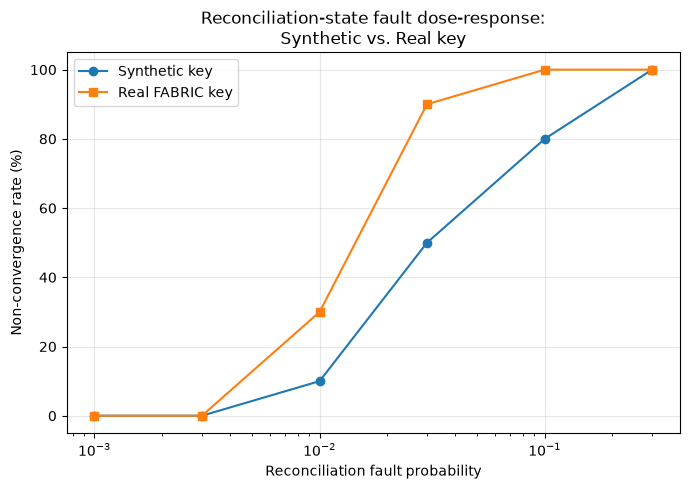


=== Synthetic vs Real: Reconciliation Non-Convergence Comparison ===
 reconciliation_prob  non_convergent_rate_synthetic  non_convergent_rate_real
               0.001                            0.0                       0.0
               0.003                            0.0                       0.0
               0.010                            0.1                       0.3
               0.030                            0.5                       0.9
               0.100                            0.8                       1.0
               0.300                            1.0                       1.0


In [2]:
"""
SDC Fault Injection: Combined Data Analysis
Synthetic-key dose-response results + real FABRIC-key validation results.
"""
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_DIR))
sys.path.insert(0, str(PROJECT_DIR / 'scripts'))
RESULTS = PROJECT_DIR / "results"


# ------------------------------------------------------------------
# 1. Load all result files
# ------------------------------------------------------------------
synthetic_toeplitz_hash = pd.read_csv(RESULTS / "sdc_toeplitz_hash_dose_response.csv")
synthetic_reconciliation = pd.read_csv(RESULTS / "sdc_reconciliation_dose_response.csv")
real_key_results = pd.read_csv(RESULTS / "sdc_real_key_results.csv")
real_key_reconciliation = pd.read_csv(RESULTS / "sdc_real_key_reconciliation_doseresponse.csv")

print("Loaded:")
for name, df in [("synthetic_toeplitz_hash", synthetic_toeplitz_hash),
                  ("synthetic_reconciliation", synthetic_reconciliation),
                  ("real_key_results", real_key_results),
                  ("real_key_reconciliation", real_key_reconciliation)]:
    print(f"  {name}: {len(df)} rows")


# ------------------------------------------------------------------
# 2. Mismatch rate helper (shared across all analyses)
# ------------------------------------------------------------------
def compute_mismatch_rate(df):
    converged = df[~df["non_convergent"]]
    if len(converged) == 0:
        return float("nan"), 0
    mismatch_rate = (~converged["keys_match"].astype(bool)).mean()
    return mismatch_rate, len(converged)


# ------------------------------------------------------------------
# 3. Synthetic dose-response: Toeplitz + Hash
# ------------------------------------------------------------------
print("\n=== Synthetic: Toeplitz + Hash dose-response ===")
for label, group in synthetic_toeplitz_hash.groupby("condition"):
    rate, n = compute_mismatch_rate(group)
    print(f"  {label}: mismatch rate = {rate:.2%} (n_converged={n})")


# ------------------------------------------------------------------
# 4. Synthetic dose-response: Reconciliation non-convergence
# ------------------------------------------------------------------
print("\n=== Synthetic: Reconciliation non-convergence ===")
recon_summary = (
    synthetic_reconciliation.groupby("reconciliation_prob")["non_convergent"]
    .mean().reset_index(name="non_convergent_rate")
)
print(recon_summary.to_string(index=False))


# ------------------------------------------------------------------
# 5. Real key: all fault types
# ------------------------------------------------------------------
print("\n=== Real key: all fault types ===")
for label, group in real_key_results.groupby("condition"):
    rate, n = compute_mismatch_rate(group)
    non_conv_rate = group["non_convergent"].mean()
    if pd.isna(rate):
        print(f"  {label}: non-convergent rate = {non_conv_rate:.2%}, no converged trials")
    else:
        print(f"  {label}: mismatch rate = {rate:.2%} (n_converged={n}), "
              f"non-convergent rate = {non_conv_rate:.2%}")


# ------------------------------------------------------------------
# 6. Real key: reconciliation dose-response
# ------------------------------------------------------------------
print("\n=== Real key: Reconciliation dose-response ===")
real_recon_summary = (
    real_key_reconciliation.groupby("reconciliation_prob")["non_convergent"]
    .mean().reset_index(name="non_convergent_rate")
)
print(real_recon_summary.to_string(index=False))


# ------------------------------------------------------------------
# 7. Comparison plot: synthetic vs real, reconciliation non-convergence
# ------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recon_summary["reconciliation_prob"], recon_summary["non_convergent_rate"] * 100,
        marker='o', label="Synthetic key")
ax.plot(real_recon_summary["reconciliation_prob"], real_recon_summary["non_convergent_rate"] * 100,
        marker='s', label="Real FABRIC key")
ax.set(xlabel="Reconciliation fault probability", ylabel="Non-convergence rate (%)",
       title="Reconciliation-state fault dose-response:\nSynthetic vs. Real key")
ax.set_xscale("log")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / "sdc_synthetic_vs_real_comparison.png", dpi=150)
plt.show()


# ------------------------------------------------------------------
# 8. Comparison table: synthetic vs real, side by side
# ------------------------------------------------------------------
comparison = recon_summary.merge(
    real_recon_summary, on="reconciliation_prob",
    suffixes=("_synthetic", "_real"),
)
print("\n=== Synthetic vs Real: Reconciliation Non-Convergence Comparison ===")
print(comparison.to_string(index=False))

In [ ]:
"""
Full, consolidated plotting cell: all figures, final structure.
(a) Real Channel: QBER + mismatch, all three fault types (Toeplitz, Final-key, Reconciliation)
(b) Small multiples, 3 panels: Real Channel | Mock | Reconciliation (Mock vs Real Channel)
"""
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


# ============================================================
# Helper functions
# ============================================================
def wilson_ci(successes, n, confidence=0.95):
    if n == 0:
        return 0.0, 0.0, 0.0
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    p_hat = successes / n
    denom = 1 + z**2 / n
    center = (p_hat + z**2 / (2 * n)) / denom
    half_width = (z / denom) * np.sqrt(p_hat * (1 - p_hat) / n + z**2 / (4 * n**2))
    return p_hat, max(0, center - half_width), min(1, center + half_width)


def mean_ci(values, confidence=0.95):
    vals = values.dropna()
    n = len(vals)
    if n == 0:
        return np.nan, np.nan, np.nan
    mean = vals.mean()
    if n > 1:
        sem = vals.std(ddof=1) / np.sqrt(n)
        half_width = stats.t.ppf(1 - (1 - confidence) / 2, df=n - 1) * sem
    else:
        half_width = 0
    return mean, mean - half_width, mean + half_width


def normalize_schema(d, channel_label):
    d = d.copy()
    if "prob" not in d.columns:
        d["prob"] = d.apply(
            lambda r: r.get("toeplitz_prob", 0) if "toeplitz" in str(r.get("condition", ""))
            else r.get("final_key_prob", 0), axis=1)
    if "fault_type" not in d.columns:
        d["fault_type"] = d["condition"].apply(
            lambda c: "toeplitz" if "toeplitz" in str(c) else "final_key")
    d["channel"] = channel_label
    return d


def rate_by_prob(df, prob_col, success_col):
    probs = sorted(df[prob_col].unique())
    rates, lo, hi = [], [], []
    for p in probs:
        sub = df[df[prob_col] == p]
        n = len(sub)
        successes = sub[success_col].fillna(False).astype(bool).sum()
        rate, rlo, rhi = wilson_ci(successes, n)
        rates.append(rate); lo.append(rlo); hi.append(rhi)
    return probs, rates, lo, hi


# ============================================================
# Load and normalize all datasets
# ============================================================

# --- Real-channel Toeplitz/Final-key (combine both files, both "Real Channel") ---
df_rc1 = pd.read_csv(str(PROJECT_DIR / "results" / "sdc_real_channel_toeplitz_finalkey_multikey.csv"))
df_rc2 = pd.read_csv(str(PROJECT_DIR / "results" / "sdc_real_channel_toeplitz_finalkey_doseresponse_multikey.csv"))
df_rc1 = normalize_schema(df_rc1, "Real Channel")
df_rc2 = normalize_schema(df_rc2, "Real Channel")
df_realchannel = pd.concat([df_rc1, df_rc2], ignore_index=True)
df_realchannel["mismatch"] = ~df_realchannel["keys_match"].fillna(False)

# --- Real-channel Reconciliation ---
df_recon_real = pd.read_csv(str(PROJECT_DIR / "results" / "sdc_real_channel_reconciliation_key0.csv"))
df_recon_real["prob"] = df_recon_real["reconciliation_prob"]
df_recon_real["fault_type"] = "reconciliation"
df_recon_real["channel"] = "Real Channel"
df_recon_real["mismatch"] = df_recon_real["remaining_errors_after_reconciliation"] > 0

# --- Combined real-channel dataset: all 3 fault types ---
df_realchannel_all = pd.concat([df_realchannel, df_recon_real], ignore_index=True)

# --- Mock (synthetic) Toeplitz/Final-key ---
df_synth = pd.read_csv(str(PROJECT_DIR / "results" / "sdc_toeplitz_finalkey_dose_response.csv"))
df_synth = normalize_schema(df_synth, "Mock")
df_synth["mismatch"] = ~df_synth["keys_match"].fillna(False)

# --- Reconciliation: Mock vs Real Channel comparison ---
df_recon_mock = pd.read_csv(str(PROJECT_DIR / "results" / "sdc_real_key_reconciliation_doseresponse.csv"))
df_recon_mock["channel"] = "Mock"
df_recon_compare = pd.concat([df_recon_mock, df_recon_real], ignore_index=True)


# ============================================================
# (a) 2-panel: QBER + mismatch, Real Channel, all 3 fault types
# ============================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5), sharex=True)

for fault_type, group_df in df_realchannel_all.groupby("fault_type"):
    probs = sorted(group_df["prob"].unique())
    qber_means, qber_lo, qber_hi = [], [], []
    mm_rates, mm_lo, mm_hi = [], [], []
    for p in probs:
        sub = group_df[group_df["prob"] == p]
        m, lo, hi = mean_ci(sub["remaining_errors_after_reconciliation"])
        qber_means.append(m); qber_lo.append(lo); qber_hi.append(hi)
        n = len(sub)
        rate, rlo, rhi = wilson_ci(sub["mismatch"].sum(), n)
        mm_rates.append(rate); mm_lo.append(rlo); mm_hi.append(rhi)

    ax1.plot(probs, qber_means, marker='o', label=fault_type)
    ax1.fill_between(probs, qber_lo, qber_hi, alpha=0.2)
    ax2.plot(probs, mm_rates, marker='o', label=fault_type)
    ax2.fill_between(probs, mm_lo, mm_hi, alpha=0.2)

ax1.set_xscale('log'); ax1.set_xlabel('Fault probability')
ax1.set_ylabel('Remaining errors after reconciliation')
ax1.set_title('QBER: silent for Toeplitz/Final-key, visible for Reconciliation')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.set_xscale('log'); ax2.set_xlabel('Fault probability')
ax2.set_ylabel('Final key mismatch rate')
ax2.set_title('Final key: all three fault types corrupt the output')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('Real Channel: Silent Data Corruption, All Three Fault Types (95% CI)')
plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "results" / "fig_a_qber_mismatch_realchannel_all3.png"), dpi=150)
plt.show()


# ============================================================
# (b) 3 panels: Toeplitz (Mock vs Real Channel) | Final-key (Mock vs Real Channel)
#     | Reconciliation (Mock vs Real Channel)
# ============================================================
df_toeplitz_compare = pd.concat([
    df_synth[df_synth["fault_type"] == "toeplitz"],
    df_realchannel[df_realchannel["fault_type"] == "toeplitz"],
], ignore_index=True)

df_finalkey_compare = pd.concat([
    df_synth[df_synth["fault_type"] == "final_key"],
    df_realchannel[df_realchannel["fault_type"] == "final_key"],
], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for channel, group_df in df_toeplitz_compare.groupby("channel"):
    probs, rates, lo, hi = rate_by_prob(group_df, "prob", "mismatch")
    axes[0].plot(probs, rates, marker='o', label=channel)
    axes[0].fill_between(probs, lo, hi, alpha=0.2)
axes[0].set_xscale('log'); axes[0].set_xlabel('Fault probability')
axes[0].set_ylabel('Mismatch rate')
axes[0].set_title('Toeplitz: Mock vs. Real Channel')
axes[0].legend(); axes[0].grid(alpha=0.3)

for channel, group_df in df_finalkey_compare.groupby("channel"):
    probs, rates, lo, hi = rate_by_prob(group_df, "prob", "mismatch")
    axes[1].plot(probs, rates, marker='o', label=channel)
    axes[1].fill_between(probs, lo, hi, alpha=0.2)
axes[1].set_xscale('log'); axes[1].set_xlabel('Fault probability')
axes[1].set_title('Final-key: Mock vs. Real Channel')
axes[1].legend(); axes[1].grid(alpha=0.3)

for channel, group_df in df_recon_compare.groupby("channel"):
    probs, rates, lo, hi = rate_by_prob(group_df, "reconciliation_prob", "non_convergent")
    axes[2].plot(probs, rates, marker='o', label=channel)
    axes[2].fill_between(probs, lo, hi, alpha=0.2)
axes[2].set_xscale('log'); axes[2].set_xlabel('Reconciliation fault probability')
axes[2].set_ylabel('Non-convergence rate')
axes[2].set_title('Reconciliation: Mock vs. Real Channel')
axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle('Mock vs. Real Channel: Toeplitz, Final-key (Mismatch Rate) and Reconciliation (Non-Convergence Rate), 95% CI')
plt.tight_layout()
plt.savefig(str(PROJECT_DIR / "results" / "fig_b_mock_vs_realchannel_3panel.png"), dpi=150)
plt.show()

print("Figure saved.")


In [ ]:
import pandas as pd
from pathlib import Path

MANIFEST = {
    # filename: (channel, fault_type_label)
    "sdc_mock_doseresponse_n50.csv": ("Mock", "toeplitz/final_key/reconciliation"),
    "sdc_mock_verifydigest_n50.csv": ("Mock", "verify_digest"),
    "sdc_toeplitz_finalkey_dose_response.csv": ("Mock", "toeplitz/final_key"),
    "sdc_reconciliation_dose_response.csv": ("Mock", "reconciliation"),
    "sdc_realchannel_toeplitz_n20.csv": ("Real", "toeplitz"),
    "sdc_realchannel_finalkey_n20.csv": ("Real", "final_key"),
    "sdc_realchannel_reconciliation_n20.csv": ("Real", "reconciliation"),
    "sdc_realchannel_verifydigest_n20.csv": ("Real", "verify_digest"),
    "sdc_real_channel_toeplitz_finalkey_multikey.csv": ("Real, multikey", "toeplitz/final_key"),
    "sdc_real_channel_toeplitz_finalkey_doseresponse_multikey.csv": ("Real, multikey", "toeplitz/final_key"),
    "sdc_real_channel_reconciliation_key0.csv": ("Real", "reconciliation"),
    "sdc_real_key_results.csv": ("Real", "baseline/combined"),
    "key_pairs_metadata.csv": ("metadata", "PE split, 5 keys"),
    "finite_key_analysis_all_keys.csv": ("derived", "finite-key lengths, 5 keys"),
    "sdc_lengthtype_comparison.csv": ("Mock", "length-type comparison, toeplitz"),
    "sdc_lengthtype_comparison_finalkey.csv": ("Mock", "length-type comparison, final_key"),
    "sdc_lengthtype_comparison_reconciliation.csv": ("Mock", "length-type comparison, reconciliation"),
}

dfs = {}
print(f"{'File':<55} {'Channel':<16} {'Rows':>6}  Columns")
print("-" * 110)
for fname, (channel, label) in MANIFEST.items():
    path = PROJECT_DIR / "results" / fname
    if not path.exists():
        print(f"{fname:<55} {'--':<16} {'--':>6}  NOT FOUND")
        continue
    df = pd.read_csv(str(path))
    dfs[fname] = df
    print(f"{fname:<55} {channel:<16} {len(df):>6}  {df.columns.tolist()}")

print(f"\nLoaded {len(dfs)} files into `dfs` dict -- access individually, e.g. dfs['sdc_realchannel_toeplitz_n20.csv']")